## Neural Network

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn

from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

## Load data

In [2]:
col_names = [
    "age", "workclass", "fnlwgt", "education", "education_num",
    "marital_status", "occupation", "relationship", "race", "sex",
    "capital_gain", "capital_loss", "hours_per_week", "native_country", "income"
]

df = pd.read_csv(
    "census+income/adult.data",
    header=None,
    names=col_names,
    sep=r",\s*",
    engine="python",
    na_values="?"
)

df = df.drop(columns=["fnlwgt"])

df["income"] = df["income"].astype(str).str.replace(".", "", regex=False).str.strip()
y = (df["income"] == ">50K").astype(int)
X = df.drop(columns=["income"])

## Organize features
same process as logistic regression for best comparison

In [3]:
numeric_features = [
    "age", "education_num", "capital_gain", "capital_loss", "hours_per_week"
]

categorical_features = [
    "workclass", "education", "marital_status", "occupation",
    "relationship", "race", "sex", "native_country"
]

In [4]:
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocess = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features),
    ]
)


In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.25,
    random_state=11,
    stratify=y
)

X_train_processed = preprocess.fit_transform(X_train)
X_test_processed = preprocess.transform(X_test)

## Convert to PyTorch tensors

In [6]:
device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
print("Using device:", device)

X_train_tensor = torch.tensor(X_train_processed.toarray(), dtype=torch.float32).to(device)
X_test_tensor = torch.tensor(X_test_processed.toarray(), dtype=torch.float32).to(device)

y_train_tensor = torch.tensor(y_train.values, dtype=torch.long).to(device)
y_test_tensor = torch.tensor(y_test.values, dtype=torch.long).to(device)

Using device: cpu


## Define MLP model
two hidden layers: one of size 64 and the other of size 32

In [13]:
class MLP(nn.Module):
    def __init__(self, input_size):
        super().__init__()

        self.network = nn.Sequential(
            nn.Linear(input_size, 1),
            nn.ReLU(),
            nn.Linear(1, 2)
        )

    def forward(self, x):
        return self.network(x)

model = MLP(X_train_tensor.shape[1]).to(device)


## Train model

In [14]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)

epochs = 100

for epoch in range(epochs):
    model.train()

    outputs = model(X_train_tensor)
    loss = criterion(outputs, y_train_tensor)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    if (epoch + 1) % 5 == 0:
        print(f"Epoch {epoch+1}/{epochs}, Loss: {loss.item():.4f}")

Epoch 5/100, Loss: 0.5200
Epoch 10/100, Loss: 0.4883
Epoch 15/100, Loss: 0.4605
Epoch 20/100, Loss: 0.4381
Epoch 25/100, Loss: 0.4204
Epoch 30/100, Loss: 0.4065
Epoch 35/100, Loss: 0.3954
Epoch 40/100, Loss: 0.3861
Epoch 45/100, Loss: 0.3784
Epoch 50/100, Loss: 0.3719
Epoch 55/100, Loss: 0.3664
Epoch 60/100, Loss: 0.3616
Epoch 65/100, Loss: 0.3575
Epoch 70/100, Loss: 0.3539
Epoch 75/100, Loss: 0.3507
Epoch 80/100, Loss: 0.3479
Epoch 85/100, Loss: 0.3454
Epoch 90/100, Loss: 0.3432
Epoch 95/100, Loss: 0.3412
Epoch 100/100, Loss: 0.3394


In [ ]:
model.eval()

with torch.no_grad():
    outputs = model(X_test_tensor)
    probs = torch.softmax(outputs, dim=1)
    y_pred_tensor = torch.argmax(outputs, dim=1)

y_pred = y_pred_tensor.cpu().numpy()
y_proba = probs[:, 1].cpu().numpy()

accuracy = accuracy_score(y_test, y_pred)
cm = confusion_matrix(y_test, y_pred)

print("MLP Accuracy:", accuracy)
print("\nConfusion matrix:\n", cm)
print("\nClassification report:\n", classification_report(y_test, y_pred))

# Print learned parameters with feature names and source columns.
feature_names = preprocess.get_feature_names_out()
first_layer = model.network[0]
output_layer = model.network[2]

input_weights = first_layer.weight.detach().cpu().numpy().flatten()
input_bias = first_layer.bias.detach().cpu().numpy().flatten()

def infer_original_column(processed_feature_name):
    suffix = processed_feature_name.split("__", 1)[-1]

    if suffix in numeric_features:
        return suffix

    for col in sorted(categorical_features, key=len, reverse=True):
        if suffix == col or suffix.startswith(f"{col}_"):
            return col

    return suffix

weights_df = pd.DataFrame({
    "processed_feature": feature_names,
    "original_column": [infer_original_column(name) for name in feature_names],
    "weight": input_weights
})

print("\nInput layer weights by feature:")
print(weights_df.to_string(index=False))
print("\nInput layer bias:", input_bias)

print("\nOutput layer weights (from hidden neuron to class logits):")
print(output_layer.weight.detach().cpu().numpy())
print("Output layer bias:", output_layer.bias.detach().cpu().numpy())

MLP Accuracy: 0.8490357449944724

Confusion matrix:
 [[5764  417]
 [ 812 1148]]

Classification report:
               precision    recall  f1-score   support

           0       0.88      0.93      0.90      6181
           1       0.73      0.59      0.65      1960

    accuracy                           0.85      8141
   macro avg       0.81      0.76      0.78      8141
weighted avg       0.84      0.85      0.84      8141


Input layer weights by feature:
                             processed_feature original_column    weight
                                      num__age             age  0.181708
                            num__education_num   education_num  0.329934
                             num__capital_gain    capital_gain  0.853722
                             num__capital_loss    capital_loss  0.142050
                           num__hours_per_week  hours_per_week  0.214231
                    cat__workclass_Federal-gov       workclass  0.366640
                      ca

,class,precision,recall
0,0,0.876521,0.932535
1,1,0.733546,0.585714


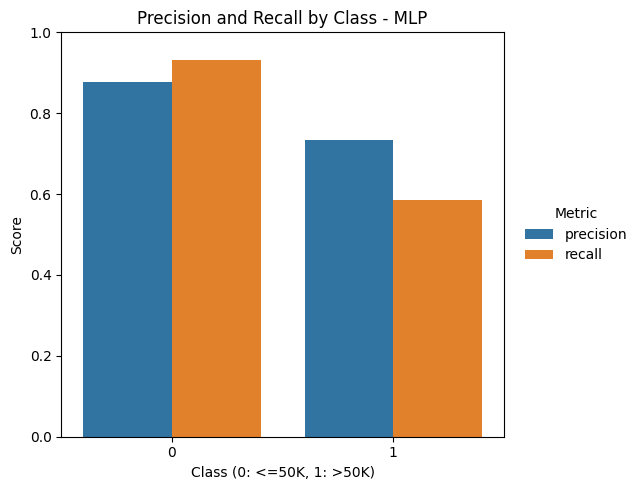

In [16]:
report_dict = classification_report(y_test, y_pred, output_dict=True)
report_df = pd.DataFrame(report_dict).T

class_rows = [str(c) for c in sorted(set(y_test))]
metrics_df = report_df.loc[class_rows, ["precision", "recall"]].reset_index()
metrics_df = metrics_df.rename(columns={"index": "class"})
metrics_long = metrics_df.melt(id_vars="class", var_name="metric", value_name="score")

display(metrics_df)

fig, ax = plt.subplots(figsize=(8, 5))
sns.barplot(
    data=metrics_long,
    x="class",
    y="score",
    hue="metric",
    ax=ax
)
ax.set_ylim(0, 1)
ax.set_title("Precision and Recall by Class - MLP")
ax.set_xlabel("Class (0: <=50K, 1: >50K)")
ax.set_ylabel("Score")
ax.legend(title="Metric", loc="center left", bbox_to_anchor=(1.02, 0.5), frameon=False)
fig.tight_layout(rect=[0, 0, 0.82, 1])
plt.show()

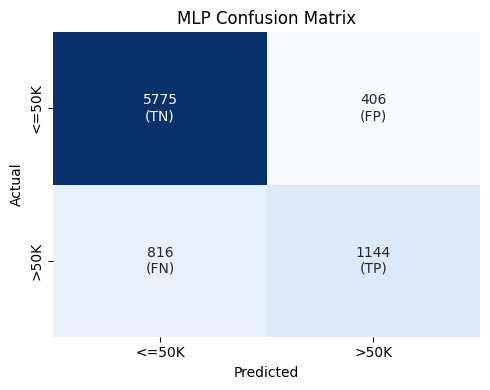

In [11]:
cell_labels = np.array([["TN", "FP"], ["FN", "TP"]])
annot_labels = np.array([
    [f"{cm[i, j]}\n({cell_labels[i, j]})" for j in range(2)]
    for i in range(2)
], dtype=object)

plt.figure(figsize=(5, 4))
sns.heatmap(
    cm,
    annot=annot_labels,
    fmt="",
    cmap="Blues",
    cbar=False,
    xticklabels=["<=50K", ">50K"],
    yticklabels=["<=50K", ">50K"]
)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("MLP Confusion Matrix")
plt.tight_layout()
plt.show()

In [ ]:
os.makedirs("exports", exist_ok=True)
mlp_cm_path = os.path.join("exports", "mlp_confusion_matrix.csv")
np.savetxt(mlp_cm_path, cm, fmt="%d", delimiter=",")

mlp_probs_path = os.path.join("exports", "mlp_probs.csv")
np.savetxt(mlp_probs_path, np.column_stack([y_test.to_numpy(), y_proba]), delimiter=",")

print(f"Saved MLP confusion matrix to: {mlp_cm_path}")
print(f"Saved MLP probabilities to: {mlp_probs_path}")

Saved MLP confusion matrix to: exports\mlp_confusion_matrix.csv
